In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.ticker import MaxNLocator
import matplotlib.ticker as ticker
import matplotlib.patches as mpl_patches
from scipy.stats import spearmanr

In [2]:
df = pd.read_table('Europe_677_accession.txt')
df.head()

,Mg25,Latitude,Longitude,bio1,bio2,bio3,bio4,bio5,bio6,bio7,...,silt,ph,CN,CEC,CaCO3,N,P,K,Mg_MMI_07,Mg_MMI_72
0,6425.217028,55.9473,13.8210,6.800000,7.100000,29.831934,632.671082,20.400000,-3.4,23.799999,...,26.771446,5.099498,16.017828,11.404053,8.995235,2.903223,34.881931,99.043198,2.0,37.0
1,6106.090545,55.7714,14.1208,7.400000,6.966667,29.645391,620.901123,21.000000,-2.5,23.500000,...,18.155411,5.306688,16.933012,11.273796,11.339157,2.775039,43.916851,128.464050,3.0,40.0
2,5937.667641,49.4112,16.2815,7.395833,8.241667,30.079075,733.808411,22.500000,-4.9,27.400000,...,37.807838,5.724783,10.382457,11.531424,0.000000,2.134119,38.884171,205.518021,3.0,47.0
3,5936.194976,55.4234,13.9905,7.937500,6.741666,28.566383,631.276184,21.299999,-2.3,23.599998,...,21.127319,6.321225,11.384063,13.246228,10.353964,2.153087,56.946087,138.103867,2.0,39.0
4,5842.619693,50.0667,8.5333,10.337500,8.458333,32.532051,672.647827,25.100000,-0.9,26.000000,...,27.917473,6.733436,13.335432,11.836184,54.417881,1.570549,32.795654,158.965622,3.0,43.0


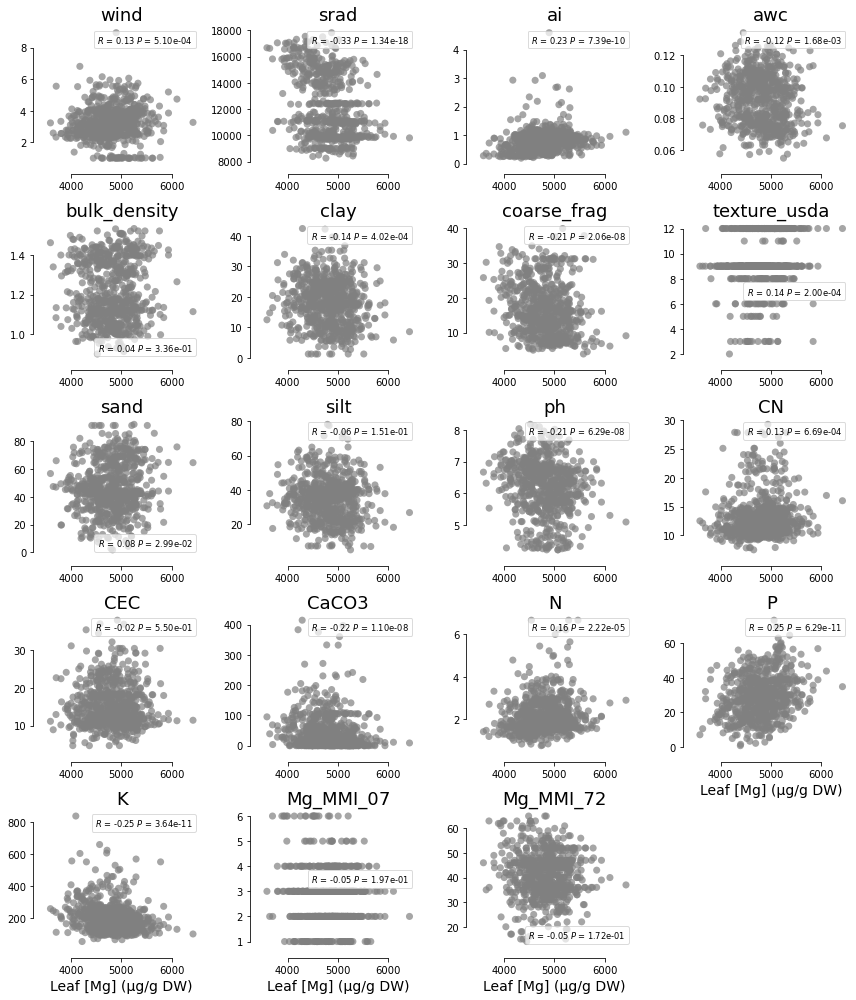

In [4]:
other=['wind','srad','ai','awc',
       'bulk_density','clay','coarse_frag','texture_usda',
       'sand','silt','ph','CN','CEC',
       'CaCO3','N','P','K', 'Mg_MMI_07','Mg_MMI_72']

def plots(var,idx1,idx2):
    sns.scatterplot(x='Mg25',
                    y=var,
                    color='grey',
                    edgecolor='none',
                    marker='o',
                    s=50,
                    alpha=0.7,
                    data=df,
                    ax=axes[idx1,idx2])

    handles = [mpl_patches.Rectangle((0, 0), 1, 1, fc="white", ec="white", 
                                 lw=0, alpha=0)] * 2
    labels = []
    r,p = spearmanr(df[var],df['Mg25'])
    labels.append(r"$\itR$ = {:.2f} $P$ = {:.2e}".format(r,p))
    axes[idx1,idx2].legend(handles, labels, loc='best', fontsize='small', 
          fancybox=True, framealpha=0.7, 
          handlelength=0, handletextpad=0)
    axes[idx1,idx2].set_xlabel('')
    axes[idx1,idx2].set_ylabel('')
    axes[idx1,idx2].set_title(var,fontsize=18)
#     axes[idx1,idx2].xaxis.set_major_locator(ticker.MultipleLocator(1))
    
    
fig,axes = plt.subplots(5,4,sharey=False,figsize=(12,14))
a,b=0,0
# for index, value in enumerate(elements):
for index in range(len(other)):
    if index % 4 == 0:
        if index == 0:
            plots(other[index],a,b)
            b+=1
        elif index == 16:
            a+=1
            b=0
            plots(other[index],a,b)
            axes[a,b].set_xlabel('Leaf [Mg] (µg/g DW)',fontsize=14)
            b+=1
        else:
            a+=1
            b=0
            plots(other[index],a,b)
            b+=1
    elif index == 15: 
        plots(other[index],a,b)
        axes[a,b].set_xlabel('Leaf [Mg] (µg/g DW)',fontsize=14)
        b+=1
    elif index > 15:
            if index == 18:
                plots(other[index],a,b)
                axes[a,b].set_xlabel('Leaf [Mg] (µg/g DW)',fontsize=14)
                axes[a,b+1].axis('off')
            else:  
                plots(other[index],a,b)
                axes[a,b].set_xlabel('Leaf [Mg] (µg/g DW)',fontsize=14)
                b+=1
    else:
        plots(other[index],a,b)
        b+=1
sns.despine(offset=10, trim=True)
plt.tight_layout()
# plt.savefig("FigS3.pdf", format="pdf",bbox_inches="tight",facecolor="w")